In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, expon, beta

# Set the visual style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# --- Question 1 Part (a) ---

np.random.seed(101)  # Set seed for reproducibility

# Parameters for the target Gaussian distribution
TARGET_MEAN = 5
TARGET_STD = 1
NUM_SAMPLES = 6000
BURN_IN_PCT = 0.25

def log_target_density(x):
    """Computes log-probability density of Gaussian(5, 1)."""
    return norm.logpdf(x, loc=TARGET_MEAN, scale=TARGET_STD)

def run_metropolis_sampler(iterations, initial_val=0.0):
    """
    Runs a Metropolis sampler with a symmetric Gaussian proposal.
    """
    chain = [initial_val]
    accept_count = 0

    current_x = initial_val
    current_log_prob = log_target_density(current_x)

    for _ in range(iterations - 1):
        # 1. Propose a new state using a symmetric Gaussian perturbation
        proposal_x = current_x + np.random.normal(scale=1.0)
        proposal_log_prob = log_target_density(proposal_x)

        # 2. Calculate acceptance ratio in log domain to avoid underflow
        # log(alpha) = log(p(x')/p(x)) = log(p(x')) - log(p(x))
        log_alpha = proposal_log_prob - current_log_prob

        # 3. Accept or Reject
        if np.log(np.random.rand()) < log_alpha:
            current_x = proposal_x
            current_log_prob = proposal_log_prob
            accept_count += 1

        chain.append(current_x)

    return np.array(chain), accept_count / iterations

# Execute the sampler
chain_q1, acc_rate_q1 = run_metropolis_sampler(NUM_SAMPLES)

# Remove burn-in samples
burn_in_idx = int(NUM_SAMPLES * BURN_IN_PCT)
clean_chain_q1 = chain_q1[burn_in_idx:]

# Output statistics
print(f"--- Question 1 Results ---")
print(f"Global Acceptance Rate: {acc_rate_q1:.2%}")
print(f"Estimated Mean: {np.mean(clean_chain_q1):.4f} (True: {TARGET_MEAN})")
print(f"Estimated Std Dev: {np.std(clean_chain_q1):.4f} (True: {TARGET_STD})")

--- Question 1 Results ---
Global Acceptance Rate: 70.53%
Estimated Mean: 4.9548 (True: 5)
Estimated Std Dev: 1.0105 (True: 1)


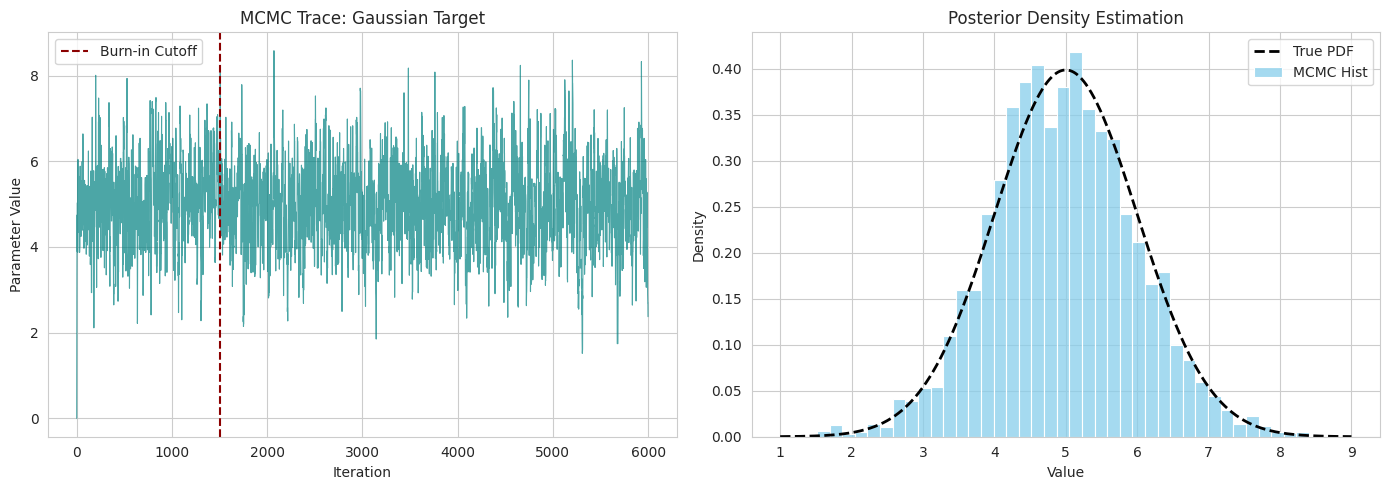

In [ ]:
# --- Question 1 Part (b) ---

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MCMC Trace
ax[0].plot(chain_q1, color='teal', alpha=0.7, linewidth=0.8)
ax[0].axvline(burn_in_idx, color='darkred', linestyle='--', label='Burn-in Cutoff')
ax[0].set_title("MCMC Trace: Gaussian Target")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Parameter Value")
ax[0].legend()

# Plot 2: Histogram vs Analytical PDF
x_axis = np.linspace(1, 9, 1000)
y_axis = norm.pdf(x_axis, TARGET_MEAN, TARGET_STD)

sns.histplot(clean_chain_q1, stat='density', bins=40, color='skyblue', label='MCMC Hist', ax=ax[1])
ax[1].plot(x_axis, y_axis, 'k--', linewidth=2, label='True PDF')
ax[1].set_title("Posterior Density Estimation")
ax[1].set_xlabel("Value")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Question 2 Part (a) ---

# Parameters
RATE_PARAM = 0.5  # Lambda for Exponential Distribution
TOTAL_STEPS = 6000
BURN_IDX = int(0.2 * TOTAL_STEPS)

def target_exp_pdf(x):
    """Target probability density: Exponential(0.5)."""
    if x < 0: return 0
    return RATE_PARAM * np.exp(-RATE_PARAM * x)

def run_mh_asymmetric(steps):
    """
    Runs Metropolis-Hastings with an asymmetric proposal (additive exponential noise).
    Includes the Hastings correction factor.
    """
    chain = np.zeros(steps)
    chain[0] = 1.0 # Initialize
    accepted_moves = 0

    for i in range(1, steps):
        current_x = chain[i-1]

        # Proposal mechanism: x' = x + E, where E ~ Exp(1)
        # This is asymmetric: we only jump in the positive direction relative to x
        step_size = np.random.exponential(scale=1.0)
        proposed_x = current_x + step_size

        # Hastings Ratio (Proposal Correction)
        # correction = q(x | x') / q(x' | x)
        # Given our proposal, this simplifies to exp(proposed - current)
        proposal_correction = np.exp(proposed_x - current_x)

        # Target Ratio: p(x') / p(x)
        target_ratio = target_exp_pdf(proposed_x) / target_exp_pdf(current_x)

        # Full Acceptance Probability
        alpha = target_ratio * proposal_correction

        if np.random.rand() < min(1, alpha):
            chain[i] = proposed_x
            accepted_moves += 1
        else:
            chain[i] = current_x

    return chain, accepted_moves / steps

# Run sampler
chain_q2, acc_rate_q2 = run_mh_asymmetric(TOTAL_STEPS)
clean_chain_q2 = chain_q2[BURN_IDX:]

# Output statistics
print(f"--- Question 2 Results ---")
print(f"MH Acceptance Rate: {acc_rate_q2:.2%}")
print(f"Estimated Mean: {np.mean(clean_chain_q2):.4f}")
print(f"Theoretical Mean (1/lambda): {1/RATE_PARAM:.4f}")

--- Question 2 Results ---
MH Acceptance Rate: 24.77%
Estimated Mean: 1480.2932
Theoretical Mean (1/lambda): 2.0000


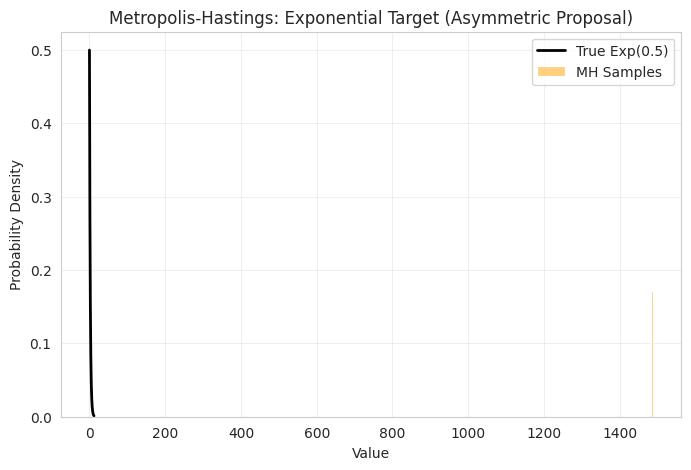

In [ ]:
# --- Question 2 Part (b) ---

plt.figure(figsize=(8, 5))

# Plot Histogram of MCMC samples
sns.histplot(clean_chain_q2, bins=50, stat="density", color="orange", alpha=0.5, label="MH Samples")

# Plot True Analytical Curve
x_grid = np.linspace(0, 12, 500)
true_curve = expon.pdf(x_grid, scale=1/RATE_PARAM)
plt.plot(x_grid, true_curve, color='black', lw=2, linestyle='-', label="True Exp(0.5)")

plt.title("Metropolis-Hastings: Exponential Target (Asymmetric Proposal)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- Question 3 Part (a) ---

# 1. Data Generation
np.random.seed(55)
TRUE_BIAS = 0.6
NUM_FLIPS = 100

data = np.random.binomial(1, TRUE_BIAS, NUM_FLIPS)
num_heads = np.sum(data)
num_tails = NUM_FLIPS - num_heads

print(f"Data Observation: {num_heads} Heads, {num_tails} Tails")

def log_unnormalized_posterior(p, h, t):
    """
    Computes log(Likelihood * Prior).
    Prior is Uniform Beta(1,1), so log(Prior) = 0.
    """
    if p < 0 or p > 1:
        return -np.inf
    # Log Likelihood: h*ln(p) + t*ln(1-p)
    return h * np.log(p) + t * np.log(1 - p)

# 2. MCMC Inference
MCMC_STEPS = 12000
RW_SIGMA = 0.08 # Width of the random walk proposal

bias_chain = np.zeros(MCMC_STEPS)
bias_chain[0] = 0.5 # Initialize at fair coin
success_count = 0

for i in range(1, MCMC_STEPS):
    current_p = bias_chain[i-1]

    # Propose new p via symmetric Random Walk
    proposed_p = current_p + np.random.normal(0, RW_SIGMA)

    # Ensure proposal is within valid probability bounds [0, 1]
    if 0 < proposed_p < 1:
        log_alpha = (log_unnormalized_posterior(proposed_p, num_heads, num_tails) -
                     log_unnormalized_posterior(current_p, num_heads, num_tails))

        if np.log(np.random.rand()) < log_alpha:
            current_p = proposed_p
            success_count += 1

    bias_chain[i] = current_p

# Discard burn-in
burn_count = 2000
final_bias_chain = bias_chain[burn_count:]

# Statistics
mean_est = np.mean(final_bias_chain)
ci_lower, ci_upper = np.percentile(final_bias_chain, [2.5, 97.5])

print(f"--- Question 3 Results ---")
print(f"Sampler Acceptance Rate: {success_count/MCMC_STEPS:.2%}")
print(f"Posterior Mean Estimate: {mean_est:.4f}")
print(f"95% Credible Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

Data Observation: 57 Heads, 43 Tails
--- Question 3 Results ---
Sampler Acceptance Rate: 56.60%
Posterior Mean Estimate: 0.5681
95% Credible Interval: [0.4717, 0.6616]


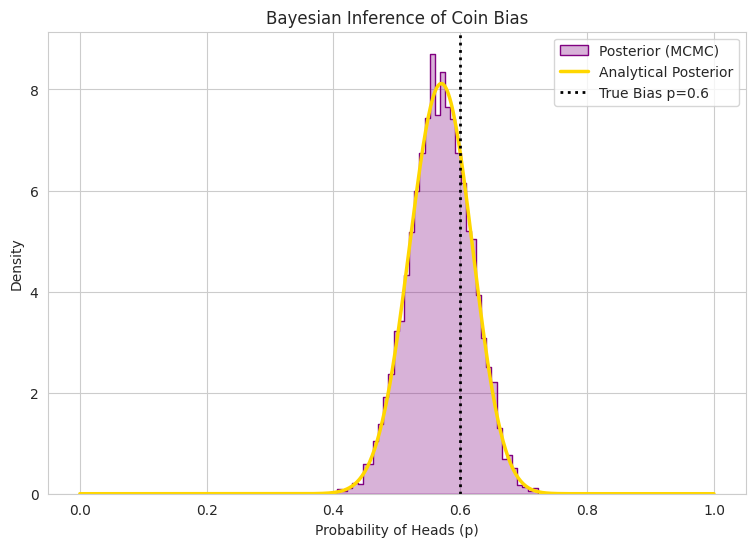

In [ ]:
# --- Question 3 Part (b) ---

plt.figure(figsize=(9, 6))

# Histogram of MCMC samples
sns.histplot(final_bias_chain, bins=40, stat='density',
             color='purple', label='Posterior (MCMC)', element="step", alpha=0.3)

# Analytical Posterior (Beta Distribution)
# With Uniform Prior Beta(1,1), the Posterior is Beta(heads+1, tails+1)
x_beta = np.linspace(0, 1, 500)
y_beta = beta.pdf(x_beta, num_heads + 1, num_tails + 1)
plt.plot(x_beta, y_beta, color='gold', lw=2.5, label='Analytical Posterior')

plt.axvline(TRUE_BIAS, color='black', linestyle=':', lw=2, label=f'True Bias p={TRUE_BIAS}')
plt.xlabel("Probability of Heads (p)")
plt.ylabel("Density")
plt.title("Bayesian Inference of Coin Bias")
plt.legend()
plt.show()